**Анализ рынка вакансий hh.ru**

**Цель:** изучить рынок вакансий аналитиков по объявлениям на сайте hh.ru и определить текущие тренды для аналитиков данных

**Задачи:**

- спарсить данные с hh.ru
- определить долю позиций «аналитик данных» от общего числа вакансий
- выявить регионы, в которых сосредоточено наибольшее количество вакансий
- выявить основных работодателей
- проанализировать диапазон заработных плат
- посмотреть распределение по грейдам
- определить тип занятости и тип графика
- выявить "чистые специализации" аналитика и проанализировать в разрезе работодателей, регионов, зарплаты, грейдов.

**План проекта:**
- изучить полученные данные, провести предобработку
- определить регионы, работодателей, зарплату
- выявить "чистые специализации" аналитика
- выводы и рекомендации

Спарсим открытые данные с hh.ru без регистрации и токена через API HeadHunter

In [1]:
pip install requests

Note: you may need to restart the kernel to use updated packages.


In [2]:
import requests
import time
import json
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Конфигурация
USER_AGENT = "DataAnalyticsPetProject/2.0 (Ln0810@list.ru)"
BASE_URL = "https://api.hh.ru/vacancies"
TEXT_QUERY = "аналитик данных"
PER_PAGE = 100
MAX_PAGES = 20
SLEEP_BETWEEN_REQUESTS = 0.5

In [4]:
def fetch_vacancies():
    headers = {"User-Agent": USER_AGENT}
    all_vacancies = []
    page = 0
    pages_total = None

    while True:
        params = {
            "text": TEXT_QUERY,
            "per_page": PER_PAGE,
            "page": page
        }

        try:
            response = requests.get(BASE_URL, headers=headers, params=params)
            if response.status_code != 200:
                print(f"Ошибка {response.status_code}: {response.text}")
                break

            data = response.json()
            found = data.get("found", 0)
            pages_total = data.get("pages", 0)
            items = data.get("items", [])

            if not items:
                break

            all_vacancies.extend(items)
            print(f"Страница {page + 1}/{pages_total}, загружено вакансий: {len(all_vacancies)}/{found}")

            if page + 1 >= pages_total or page + 1 >= MAX_PAGES:
                break

            page += 1
            time.sleep(SLEEP_BETWEEN_REQUESTS)

        except Exception as e:
            print(f"Исключение при запросе: {e}")
            break

    return all_vacancies

def save_to_csv(vacancies, filename="hh_vacancies_2026.csv"):
    if not vacancies:
        print("Нет данных для сохранения.")
        return

    # Извлекаем основные поля для CSV
    rows = []
    for v in vacancies:
        row = {
            "id": v.get("id"),
            "name": v.get("name"),
            "published_at": v.get("published_at"),
            "created_at": v.get("created_at"),
            "url": v.get("alternate_url"),
            "employer": v.get("employer", {}).get("name") if v.get("employer") else None,
            "area": v.get("area", {}).get("name") if v.get("area") else None,
            "salary_from": v.get("salary", {}).get("from") if v.get("salary") else None,
            "salary_to": v.get("salary", {}).get("to") if v.get("salary") else None,
            "salary_currency": v.get("salary", {}).get("currency") if v.get("salary") else None,
            "experience": v.get("experience", {}).get("name") if v.get("experience") else None,
            "employment": v.get("employment", {}).get("name") if v.get("employment") else None,
            "schedule": v.get("schedule", {}).get("name") if v.get("schedule") else None,
        }
        rows.append(row)

    df = pd.DataFrame(rows)
    df.to_csv(filename, index=False, encoding="utf-8-sig")
    print(f"Сохранено {len(df)} вакансий в {filename}")

if __name__ == "__main__":
    print("Начинаем загрузку актуальных вакансий...")
    vacancies = fetch_vacancies()
    if vacancies:
        save_to_csv(vacancies, filename="D:/Docs/Natali/Pet_проект/hh_vacancies_2026.csv")
    else:
        print("Вакансии за 2026 год не найдены.")

Начинаем загрузку актуальных вакансий...
Ошибка 403: {"errors":[{"type":"forbidden"}],"request_id":"17806508413388085f90b439fe3b4007"}
Вакансии за 2026 год не найдены.


*На данный момент сайт hh.ru не дает скачать данные без регистрации, поэтому выходит ошибка 403.*

## Изучение данных и предобработка данных

In [5]:
# Читаем CSV-файл
df = pd.read_csv('hh_vacancies.csv', encoding='utf-8-sig')

# Выводим первые 10 строк
df.head(20)

,id,name,published_at,created_at,url,employer,area,salary_from,salary_to,salary_currency,experience,employment,schedule
0,131508219,Аналитик данных,2026-04-14T14:02:53+0300,2026-04-14T14:02:53+0300,https://hh.ru/vacancy/131508219,СП ООО AZIA METALL PROF,Самарканд,6000000.0,12000000.0,UZS,От 1 года до 3 лет,Полная занятость,Полный день
1,132118624,Аналитик данных,2026-04-14T12:32:40+0300,2026-04-14T12:32:40+0300,https://hh.ru/vacancy/132118624,Служба занятости населения города Москвы,Москва,65000.0,65000.0,RUR,От 1 года до 3 лет,Полная занятость,Полный день
2,131775933,Аналитик данных,2026-04-14T12:23:50+0300,2026-04-14T12:23:50+0300,https://hh.ru/vacancy/131775933,Газпром нефть,Екатеринбург,NaN,NaN,NaN,От 1 года до 3 лет,Полная занятость,Полный день
3,131607371,Аналитик данных,2026-04-14T12:03:46+0300,2026-04-14T12:03:46+0300,https://hh.ru/vacancy/131607371,Алюсофт,Минск,NaN,NaN,NaN,От 1 года до 3 лет,Полная занятость,Полный день
4,132123805,Дата-аналитик,2026-04-14T13:52:00+0300,2026-04-14T13:52:00+0300,https://hh.ru/vacancy/132123805,СБЕР,Москва,NaN,NaN,NaN,От 1 года до 3 лет,Полная занятость,Полный день
5,132109716,Аналитик данных,2026-04-14T10:15:00+0300,2026-04-14T10:15:00+0300,https://hh.ru/vacancy/132109716,СБЕР,Москва,NaN,NaN,NaN,От 3 до 6 лет,Полная занятость,Полный день
6,132109795,Аналитик данных,2026-04-14T10:16:07+0300,2026-04-14T10:16:07+0300,https://hh.ru/vacancy/132109795,ГКУ Центр организации дорожного движения Прави...,Москва,90000.0,100000.0,RUR,От 1 года до 3 лет,Полная занятость,Полный день
7,131951997,Дата Аналитик,2026-04-14T13:09:56+0300,2026-04-14T13:09:56+0300,https://hh.ru/vacancy/131951997,MARKETPLACE TRADING,Ташкент,15000000.0,NaN,UZS,От 1 года до 3 лет,Полная занятость,Полный день
8,132107800,Аналитик данных,2026-04-14T09:47:00+0300,2026-04-14T09:47:00+0300,https://hh.ru/vacancy/132107800,СБЕР,Москва,NaN,NaN,NaN,От 3 до 6 лет,Полная занятость,Полный день
9,130908151,Аналитик данных,2026-04-14T08:42:55+0300,2026-04-14T08:42:55+0300,https://hh.ru/vacancy/130908151,Микрофинансовая организация Шинхан Финанс,Алматы,NaN,NaN,NaN,От 1 года до 3 лет,Полная занятость,Полный день


In [6]:
# Выводим последние 20 строк
df.tail(20)

,id,name,published_at,created_at,url,employer,area,salary_from,salary_to,salary_currency,experience,employment,schedule
1980,131959839,Руководитель направления продуктовой аналитики,2026-04-08T15:50:21+0300,2026-04-08T15:50:21+0300,https://hh.ru/vacancy/131959839,Х5,Москва,NaN,NaN,NaN,От 3 до 6 лет,Полная занятость,Полный день
1981,131499980,Аналитик данных,2026-03-24T11:32:00+0300,2026-03-24T11:32:00+0300,https://hh.ru/vacancy/131499980,ТЕХНОЛОГИИ ОТРАСЛЕВОЙ ТРАНСФОРМАЦИИ,Москва,NaN,NaN,NaN,От 3 до 6 лет,Полная занятость,Полный день
1982,131907266,Аналитик партнёрских продаж,2026-04-07T11:43:48+0300,2026-04-07T11:43:48+0300,https://hh.ru/vacancy/131907266,Единая Сервисная Платформа,Москва,NaN,NaN,NaN,От 3 до 6 лет,Полная занятость,Полный день
1983,131496729,Аналитик данных,2026-03-24T10:41:02+0300,2026-03-24T10:41:02+0300,https://hh.ru/vacancy/131496729,Бургер БК / Сеть ресторанов Бургер Кинг,Минск,2700.0,3200.0,BYR,От 1 года до 3 лет,Полная занятость,Полный день
1984,131885177,Начинающий бизнес-аналитик,2026-04-06T17:25:45+0300,2026-04-06T17:25:45+0300,https://hh.ru/vacancy/131885177,Межрегиональное Управление Федерального Казнач...,Москва,NaN,NaN,NaN,Нет опыта,Полная занятость,Полный день
1985,131961015,Системный аналитик 1С,2026-04-08T16:12:41+0300,2026-04-08T16:12:41+0300,https://hh.ru/vacancy/131961015,ФСК Северо-Запад,Санкт-Петербург,NaN,NaN,NaN,От 3 до 6 лет,Полная занятость,Полный день
1986,131491214,Аналитик данных,2026-03-24T09:08:41+0300,2026-03-24T09:08:41+0300,https://hh.ru/vacancy/131491214,ЧАКБ «ДАВР БАНК»,Ташкент,NaN,10000000.0,UZS,От 1 года до 3 лет,Полная занятость,Полный день
1987,130281640,Руководитель направления по аналитике в CRM (э...,2026-04-10T12:43:15+0300,2026-04-10T12:43:15+0300,https://hh.ru/vacancy/130281640,Альфа-Банк,Москва,NaN,NaN,NaN,От 1 года до 3 лет,Полная занятость,Полный день
1988,131493611,Аналитик данных,2026-03-24T09:49:50+0300,2026-03-24T09:49:50+0300,https://hh.ru/vacancy/131493611,СБЕР,Нижний Новгород,NaN,NaN,NaN,От 3 до 6 лет,Полная занятость,Полный день
1989,131829072,Ведущий аналитик по эффективности гипермаркетов,2026-04-09T09:12:39+0300,2026-04-09T09:12:39+0300,https://hh.ru/vacancy/131829072,"МАГНИТ, Розничная сеть",Краснодар,99400.0,NaN,RUR,От 1 года до 3 лет,Полная занятость,Полный день


In [7]:
# Информация о DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               2000 non-null   int64  
 1   name             2000 non-null   object 
 2   published_at     2000 non-null   object 
 3   created_at       2000 non-null   object 
 4   url              2000 non-null   object 
 5   employer         2000 non-null   object 
 6   area             2000 non-null   object 
 7   salary_from      579 non-null    float64
 8   salary_to        379 non-null    float64
 9   salary_currency  672 non-null    object 
 10  experience       2000 non-null   object 
 11  employment       2000 non-null   object 
 12  schedule         2000 non-null   object 
dtypes: float64(2), int64(1), object(10)
memory usage: 203.2+ KB


In [8]:
# Общее количество строк
total_rows = df.shape[0]           

# Общее количество столбцов
total_columns = df.shape[1]       

print(f"\nОбщее количество строк: {total_rows}")
print(f"Общее количество столбцов: {total_columns}")


Общее количество строк: 2000
Общее количество столбцов: 13


**Вывод:** мы имеем 13 столбцов и 2000 строк, Тип данных у большинства - object. Запрлата "salary_from" и "salary_to " имеет тип - float64. Столбцы "published_at" и "created_at" с object можно изменить на дату (datetime). Есть пропуски

In [9]:
# Преобразуем строки в datetime (pandas автоматически распознает +0300)
df['published_at'] = pd.to_datetime(df['published_at'])
df['created_at'] = pd.to_datetime(df['created_at'])

# Теперь убираем часовой пояс и нормализуем до начала дня
df['published_date'] = df['published_at'].dt.tz_localize(None).dt.normalize()
df['created_date'] = df['created_at'].dt.tz_localize(None).dt.normalize()

# Проверяем результат
print(df[['published_date', 'created_date']].dtypes)
print(df[['published_date', 'created_date']].head(10))

published_date    datetime64[ns]
created_date      datetime64[ns]
dtype: object
  published_date created_date
0     2026-04-14   2026-04-14
1     2026-04-14   2026-04-14
2     2026-04-14   2026-04-14
3     2026-04-14   2026-04-14
4     2026-04-14   2026-04-14
5     2026-04-14   2026-04-14
6     2026-04-14   2026-04-14
7     2026-04-14   2026-04-14
8     2026-04-14   2026-04-14
9     2026-04-14   2026-04-14


In [10]:
# Проверим преобразование
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype                                
---  ------           --------------  -----                                
 0   id               2000 non-null   int64                                
 1   name             2000 non-null   object                               
 2   published_at     2000 non-null   datetime64[ns, pytz.FixedOffset(180)]
 3   created_at       2000 non-null   datetime64[ns, pytz.FixedOffset(180)]
 4   url              2000 non-null   object                               
 5   employer         2000 non-null   object                               
 6   area             2000 non-null   object                               
 7   salary_from      579 non-null    float64                              
 8   salary_to        379 non-null    float64                              
 9   salary_currency  672 non-null    object             

In [11]:
# Сделаем копию датафрейма
df_copy = df.copy()

In [12]:
# Удаляем старые столбцы
df_copy = df.drop(['published_at', 'created_at'], axis=1)

In [13]:
# Проверим преобразование
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   id               2000 non-null   int64         
 1   name             2000 non-null   object        
 2   url              2000 non-null   object        
 3   employer         2000 non-null   object        
 4   area             2000 non-null   object        
 5   salary_from      579 non-null    float64       
 6   salary_to        379 non-null    float64       
 7   salary_currency  672 non-null    object        
 8   experience       2000 non-null   object        
 9   employment       2000 non-null   object        
 10  schedule         2000 non-null   object        
 11  published_date   2000 non-null   datetime64[ns]
 12  created_date     2000 non-null   datetime64[ns]
dtypes: datetime64[ns](2), float64(2), int64(1), object(8)
memory usage: 203.2+ KB


In [14]:
# Находим минимальную и максимальную дату
print(f"С начала: {df_copy['published_date'].min()} \
      \nдо конца: {df_copy['published_date'].max()}")

print(f"С начала: {df_copy['created_date'].min()} \
      \nдо конца: {df_copy['created_date'].max()}")

С начала: 2026-03-24 00:00:00       
до конца: 2026-04-14 00:00:00
С начала: 2026-03-24 00:00:00       
до конца: 2026-04-14 00:00:00


In [15]:
# Определеяем пропуски
df_copy.isna().sum()

id                    0
name                  0
url                   0
employer              0
area                  0
salary_from        1421
salary_to          1621
salary_currency    1328
experience            0
employment            0
schedule              0
published_date        0
created_date          0
dtype: int64

In [16]:
# Подсчитываем процент строк с пропусками
df_copy.isna().sum() / len(df_copy) * 100
print(round(df_copy.isna().sum() / len(df_copy) * 100, 2))

id                  0.00
name                0.00
url                 0.00
employer            0.00
area                0.00
salary_from        71.05
salary_to          81.05
salary_currency    66.40
experience          0.00
employment          0.00
schedule            0.00
published_date      0.00
created_date        0.00
dtype: float64


In [17]:
# Проверка на явные дубликаты
print(f'Количество явных дубликатов по таблице: {df_copy.duplicated().sum()}')

Количество явных дубликатов по таблице: 1


In [18]:
# Вывод всех строк, которые являются дубликатами (включая первое вхождение)
duplicates = df_copy[df_copy.duplicated(keep=False)]
print(f"Найдено строк с дубликатами: {len(duplicates)}")
print(duplicates)

Найдено строк с дубликатами: 2
            id                 name                              url  \
699  130535670  Финансовый аналитик  https://hh.ru/vacancy/130535670   
700  130535670  Финансовый аналитик  https://hh.ru/vacancy/130535670   

             employer    area  salary_from  salary_to salary_currency  \
699  Авто Финанс Банк  Москва          NaN        NaN             NaN   
700  Авто Финанс Банк  Москва          NaN        NaN             NaN   

             experience        employment     schedule published_date  \
699  От 1 года до 3 лет  Полная занятость  Полный день     2026-04-12   
700  От 1 года до 3 лет  Полная занятость  Полный день     2026-04-12   

    created_date  
699   2026-04-12  
700   2026-04-12  


In [19]:
# Удаление дубликата
vacancies = df_copy.drop_duplicates()

In [20]:
# Проверка после удаления
duplicatess = vacancies.duplicated().sum()
print(f'\nОсталось явных дубликатов: {duplicatess}')


Осталось явных дубликатов: 0


In [21]:
# Выведем уникальные значения и их количество
for column in ['name', 'employer', 'area', 'salary_currency', 'experience', 'employment', 'schedule']:
    print(f'Значения поля {column}: {vacancies[column].unique()}\n')
    print(f'Количество уникальных значений {column}: {vacancies[column].nunique()}\n')        

Значения поля name: ['Аналитик данных' 'Дата-аналитик' 'Дата Аналитик' ...
 'Стажер BI аналитик' 'Аналитик (Инженер) развития мониторинга'
 'Аналитик CVM\\CRM (розница)']

Количество уникальных значений name: 1207

Значения поля employer: ['СП ООО AZIA METALL PROF' 'Служба занятости населения города Москвы'
 'Газпром нефть' ... 'Grand era' 'ТРАНСКАПИТАЛБАНК'
 'Яндекс Команда для бизнеса']

Количество уникальных значений employer: 1331

Значения поля area: ['Самарканд' 'Москва' 'Екатеринбург' 'Минск' 'Ташкент' 'Алматы' 'Темиртау'
 'Энгельс' 'Владивосток' 'Балашиха (Московская область)' 'Шымкент'
 'Санкт-Петербург' 'Пермь' 'Воронеж' 'Сочи' 'Бишкек' 'Астана' 'Рязань'
 'Кокшетау' 'Краснодар' 'Ош' 'Казань' 'Нижний Новгород' 'Зеленоград'
 'Петрозаводск' 'Якутск' 'Новосибирск' 'Анадырь' 'Грозный' 'Калуга'
 'Владимир' 'Орел' 'Тула' 'Красногорск (Московская область)' 'Туркестан'
 'Актобе' 'Иннополис' 'Симферополь' 'Ставрополь' 'Тараз' 'Самара'
 'Железнодорожный  (Московская область)' 'Мытищи (М

**Общий вывод:** удалили один дубликат, привели все типы данных к нужным типам для дальнейшего анализа. В большинстве вакансий зарплата не указана, и количество пропусков составляет: "salary_from" (71.05%), "salary_to" (81.05%). Также видим, что уникальные значения названия вакансий -"name" аналитиков очень большое 1207 названий. Здесь и стажеры и специалисты по аналитике и логисты-аналитики. Есть как "узкие специальности", так и "широкие специальности", включающие в себя аналитическую деятельность.

Данные представлены **с 23 марта 2026 года по 14 апреля 2026 года**.

## Определим регионы, работодателей, зарплату 

Посмотрим на зарплату аналитиков

In [22]:
vacancies.describe()

,id,salary_from,salary_to
count,1.999000e+03,5.790000e+02,3.790000e+02
mean,1.313352e+08,3.193093e+05,6.888462e+05
std,1.670247e+06,1.522933e+06,3.170410e+06
min,9.787474e+07,1.500000e+02,4.000000e+02
25%,1.312440e+08,7.110000e+04,9.000000e+04
50%,1.318178e+08,1.034500e+05,1.400000e+05
75%,1.320035e+08,1.600000e+05,2.300000e+05
max,1.321272e+08,2.000000e+07,3.200000e+07


In [23]:
# Определяем диапазон зарплаты от минимума до максимума
# Минимумы
print(f"min salary_from: {vacancies['salary_from'].min()}")
print(f"min salary_to: {vacancies['salary_to'].min()}")

# Максимумы
print(f"max salary_from: {vacancies['salary_from'].max()}")
print(f"max salary_to: {vacancies['salary_to'].max()}")

# Средние (среднее арифметическое)
print(f"avg salary_from: {vacancies['salary_from'].mean()}")
print(f"avg salary_to: {vacancies['salary_to'].mean()}")

min salary_from: 150.0
min salary_to: 400.0
max salary_from: 20000000.0
max salary_to: 32000000.0
avg salary_from: 319309.3160621762
avg salary_to: 688846.1635883905


Отфильтруем по валютам. 

In [24]:
# Фильтруем по рублям
vacancies_rur = vacancies[vacancies['salary_currency'] == 'RUR']

print(f"min salary_from: {vacancies_rur['salary_from'].min()}")
print(f"min salary_to: {vacancies_rur['salary_to'].min()}")

# Максимумы
print(f"max salary_from: {vacancies_rur['salary_from'].max()}")
print(f"max salary_to: {vacancies_rur['salary_to'].max()}")

# Средние (среднее арифметическое)
print(f"avg salary_from: {vacancies_rur['salary_from'].mean()}")
print(f"avg salary_to: {vacancies_rur['salary_to'].mean()}")

min salary_from: 1000.0
min salary_to: 2500.0
max salary_from: 900000.0
max salary_to: 1300000.0
avg salary_from: 119769.00193423597
avg salary_to: 151265.24770642203


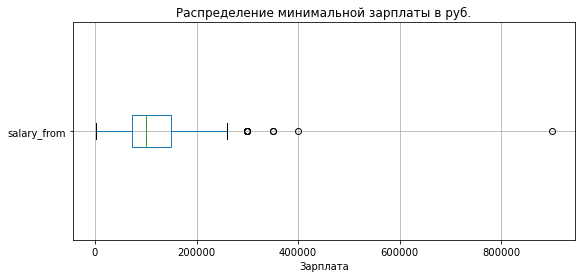

In [25]:
# Посмотрим на выбросы по зарплате в рублях
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(9, 4))

# Строим диаграмму размаха значений в столбце 'seats'
vacancies_rur.boxplot(column='salary_from', vert=False)

# Добавляем заголовок и метки оси
plt.title('Распределение минимальной зарплаты в руб.')
plt.xlabel('Зарплата')

# Выводим график
plt.show()

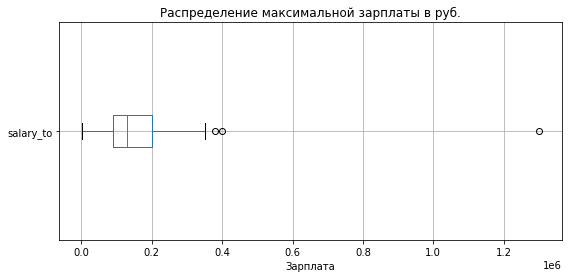

In [26]:
# Посмотрим на выбросы по зарплате в рублях
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(9, 4))

# Строим диаграмму размаха значений в столбце 'seats'
vacancies_rur.boxplot(column='salary_to', vert=False)

# Добавляем заголовок и метки оси
plt.title('Распределение максимальной зарплаты в руб.')
plt.xlabel('Зарплата')

# Выводим график
plt.show()

In [27]:
# Видим, что есть выбросы, поэтому найдем медиану в зарплате 
print(f"median salary_from: {vacancies_rur['salary_from'].median()}")
print(f"median salary_to: {vacancies_rur['salary_to'].median()}")

median salary_from: 100000.0
median salary_to: 130000.0


**Вывод:** видим, что средняя заплата **аналитика от 100 000 руб. до 130 000 руб.** Максимальная доходит дол 1300 000, но скорее всего это для очень опытных и узких специалистов.

In [28]:
# Фильтруем по доллару
vacancies_usd = vacancies[vacancies['salary_currency'] == 'USD']

# Минимумы
print(f"min salary_from: {vacancies_usd['salary_from'].min()}")
print(f"min salary_to: {vacancies_usd['salary_to'].min()}")

# Максимумы
print(f"max salary_from: {vacancies_usd['salary_from'].max()}")
print(f"max salary_to: {vacancies_usd['salary_to'].max()}")

# Средние (среднее арифметическое)
print(f"avg salary_from: {vacancies_usd['salary_from'].mean()}")
print(f"avg salary_to: {vacancies_usd['salary_to'].mean()}")

min salary_from: 150.0
min salary_to: 400.0
max salary_from: 3200.0
max salary_to: 4100.0
avg salary_from: 1612.5
avg salary_to: 2516.6666666666665


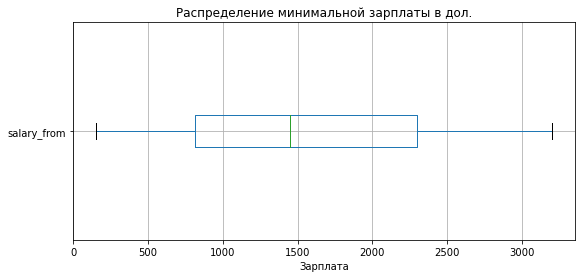

In [29]:
# Посмотрим есть ли выбросы по зарплате в дол. 
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(9, 4))

# Строим диаграмму размаха значений в столбце 'seats'
vacancies_usd.boxplot(column='salary_from', vert=False)

# Добавляем заголовок и метки оси
plt.title('Распределение минимальной зарплаты в дол.')
plt.xlabel('Зарплата')

# Выводим график
plt.show()

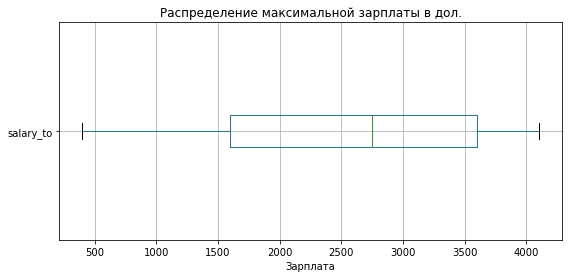

In [30]:
# Посмотрим есть ли выбросы по зарплате в дол. 
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(9, 4))

# Строим диаграмму размаха значений в столбце 'seats'
vacancies_usd.boxplot(column='salary_to', vert=False)

# Добавляем заголовок и метки оси
plt.title('Распределение максимальной зарплаты в дол.')
plt.xlabel('Зарплата')

# Выводим график
plt.show()

In [31]:
# выбросов нет, посмотрим на медианную зарплату
print(f"median salary_from: {vacancies_usd['salary_from'].median()}")
print(f"median salary_to: {vacancies_usd['salary_to'].median()}")

median salary_from: 1450.0
median salary_to: 2750.0


**Вывод:** средняя ЗП в долларах от 1450 дол. до 2750 дол.

Определим где сосредоточено большее количество вакансий, в каком регионе

In [32]:
# Определяем самые распространенные регионы с вакансиями аналитиков данных
vacancies_area = vacancies.groupby('area')['id'].nunique().sort_values(ascending=False)
total_vacancies = vacancies_area.sum()  # Общее число уникальных вакансий

print("Топ-20 регионов по числу вакансий:")
print(vacancies_area.head(20))

# Считаем проценты
vacancies_area_pct = (vacancies_area / total_vacancies * 100).round(1)

print("\nДоля каждого региона (%) — топ‑20:")
print(vacancies_area_pct.head(20))

Топ-20 регионов по числу вакансий:
area
Москва             1118
Санкт-Петербург     151
Алматы              103
Минск                52
Новосибирск          49
Ташкент              49
Екатеринбург         41
Нижний Новгород      37
Казань               33
Астана               25
Краснодар            20
Пермь                16
Самара               15
Ростов-на-Дону       13
Воронеж              12
Бишкек               11
Владивосток           9
Рязань                9
Тюмень                9
Омск                  8
Name: id, dtype: int64

Доля каждого региона (%) — топ‑20:
area
Москва             55.9
Санкт-Петербург     7.6
Алматы              5.2
Минск               2.6
Новосибирск         2.5
Ташкент             2.5
Екатеринбург        2.1
Нижний Новгород     1.9
Казань              1.7
Астана              1.3
Краснодар           1.0
Пермь               0.8
Самара              0.8
Ростов-на-Дону      0.7
Воронеж             0.6
Бишкек              0.6
Владивосток         0.5
Рязань  

In [33]:
# Последние 20 (наименьшее количество вакансий)
print("Последние 20 регионов (наименьшее число вакансий):")
print(vacancies_area.tail(20))

Последние 20 регионов (наименьшее число вакансий):
area
Иннополис                              1
Новый Уренгой                          1
ОАЭ                                    1
Обнинск                                1
Иваново (Ивановская область)           1
Зеленодольск (Республика Татарстан)    1
Оренбург                               1
Ош                                     1
Жуковский  (Московская область)        1
Егорьевск (Московская область)         1
Полоцк                                 1
Псков                                  1
Дубна (Московская область)             1
Рыбинск                                1
Домодедово (Московская область)        1
Дзержинск (Нижегородская область)      1
Самарканд                              1
Костанай                               1
Саранск                                1
Актобе                                 1
Name: id, dtype: int64


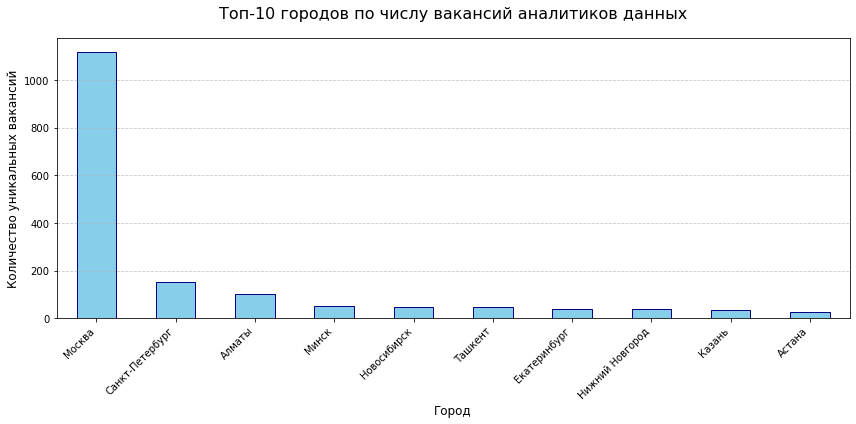

In [34]:
# Визуализируем данные по регионам

# Берём топ‑10 регионов по количеству вакансий
top_10_cities = vacancies_area.head(10)

# Строим график
plt.figure(figsize=(12, 6))
top_10_cities.plot(kind='bar', color='skyblue', edgecolor='navy', linewidth=1)

plt.title('Топ‑10 городов по числу вакансий аналитиков данных', fontsize=16, pad=20)
plt.xlabel('Город', fontsize=12)
plt.ylabel('Количество уникальных вакансий', fontsize=12)
plt.xticks(rotation=45, ha='right')  # поворачиваем подписи, чтобы не накладывались
plt.grid(axis='y', linestyle='--', alpha=0.7)  # сетка для удобства чтения
plt.tight_layout()  # автоматическая подгонка отступов
plt.show()


**Вывод:** аналитик чаще всего требуются в крупных столичных города, особенно здесь выделяется Москва (1118) - 55,9% от всех представленных вакансий, далее идут Санкт-Петербург (151) - 7,6%, Алматы (103) - 5,2%, Минск (52) - 2,6%, Новосибирск и Ташкент по 49 вакансий - 2,5%. 
Стоит отметить, что аналитики требуются и в небольших городах, хотя там число вакансий за месяц - небольшое: 1-2 вакансии.

In [35]:
# Определяем основных работодателей
vacancies_employer = vacancies.groupby('employer')['id'].nunique().sort_values(ascending=False)

# Считаем общее число уникальных вакансий
total_employer = vacancies_employer.sum()

# Рассчитываем проценты и округляем до 1 знака после запятой
vacancies_employer_pct = (vacancies_employer / total_employer * 100).round(1)

# Объединяем в один DataFrame для наглядности
result_employer = pd.DataFrame({
    'Количество вакансий': vacancies_employer,
    'Доля (%)': vacancies_employer_pct
})

# Выводим топ‑20 работодателей
display(result_employer.head(20))

,Количество вакансий,Доля (%)
employer,,
СБЕР,43,2.2
Ozon,27,1.4
МТС,21,1.1
ИЦ АЙ-ТЕКО,18,0.9
Т-Банк,15,0.8
Банк ВТБ (ПАО),15,0.8
Правительство Москвы,14,0.7
Альфа-Банк,14,0.7
Центральный банк Российской Федерации (Банк России),12,0.6


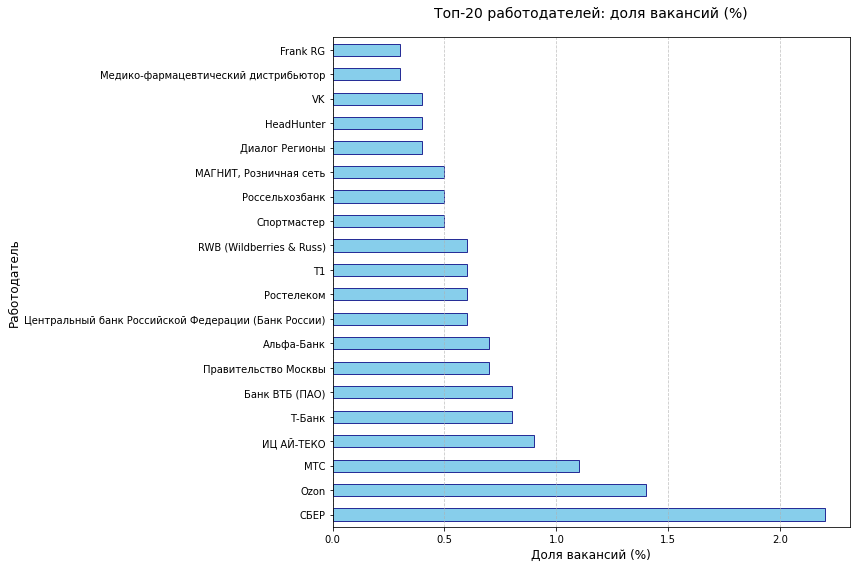

In [36]:
# Строим столбчатую диаграмму

# Берём топ‑20
top_20 = result_employer.head(20)

# Строим горизонтальную диаграмму
plt.figure(figsize=(12, 8))  # увеличили высоту для лучшей читаемости
top_20['Доля (%)'].plot(
    kind='barh',                    # ключевое изменение — горизонтальная диаграмма
    color='skyblue',
    edgecolor='navy',
    linewidth=0.8
)

plt.title('Топ‑20 работодателей: доля вакансий (%)', fontsize=14, pad=20)
plt.xlabel('Доля вакансий (%)', fontsize=12)  # теперь ось X — это проценты
plt.ylabel('Работодатель', fontsize=12)     # ось Y — названия работодателей
plt.grid(axis='x', linestyle='--', alpha=0.7)  # сетка по оси X (горизонтально)
plt.tight_layout()
plt.show()


**Вывод:** с 23 марта 2026 года по 14 апреля 2026 года наиболее ярко был представлен банковский сектор (Сбер, Т-Банк, Альфа-багк, банк России, Россельхозбанк), далее идут e-commers (Озон, Wildberries & Russ), телекомы (МТС, Ростелеком), компании IT-направления (ИЦ АЙ-ТЕКО) и ритейла (Магнит, Спортмастер). 

In [37]:
# Посчитаем, какой тип занятости встречается чаще всего
vacancies_employment = vacancies.groupby('employment')['id'].nunique().sort_values(ascending=False)
total_employment = vacancies_employment.sum()  # Общее число уникальных вакансий

# Считаем проценты и округляем до 1 знака после запятой
vacancies_employment_pct = (vacancies_employment / total_employment * 100).round(1)

# Объединяем в один DataFrame для наглядности
result_employment = pd.DataFrame({
    'Количество вакансий': vacancies_employment,
    'Доля (%)': vacancies_employment_pct
})

display(result_employment)


,Количество вакансий,Доля (%)
employment,,
Полная занятость,1955,97.8
Проектная работа,23,1.2
Частичная занятость,21,1.1


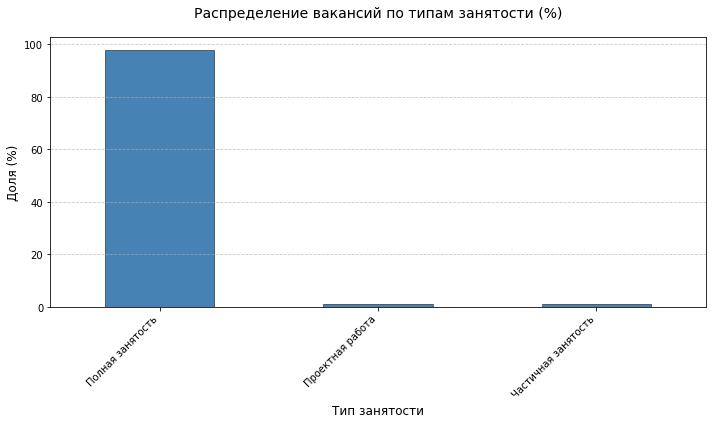

In [38]:
# Строим столбчатую диаграмму
plt.figure(figsize=(10, 6))
vacancies_employment_pct.plot(kind='bar', color='steelblue', edgecolor='black', linewidth=0.5)

plt.title('Распределение вакансий по типам занятости (%)', fontsize=14, pad=20)
plt.xlabel('Тип занятости', fontsize=12)
plt.ylabel('Доля (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')  # поворачиваем подписи, чтобы не накладывались
plt.grid(axis='y', linestyle='--', alpha=0.7)  # сетка для удобства чтения
plt.tight_layout()  # автоматическая подгонка отступов
plt.show()


In [39]:
# Посчитаем какой тип графика работы встречатся чаще всего
vacancies_schedule = vacancies.groupby('schedule')['id'].nunique().sort_values(ascending=False)
total_schedule = vacancies_schedule.sum()  # Общее число уникальных вакансий

# Считаем проценты и округляем до 1 знака после запятой
vacancies_schedule_pct = (vacancies_schedule / total_schedule * 100).round(1)

# Объединяем в один DataFrame для наглядности
result_schedule = pd.DataFrame({
    'Количество вакансий': vacancies_schedule,
    'Доля (%)': vacancies_schedule_pct
})

display(result_schedule)

,Количество вакансий,Доля (%)
schedule,,
Полный день,1540,77.0
Удаленная работа,437,21.9
Сменный график,14,0.7
Гибкий график,8,0.4


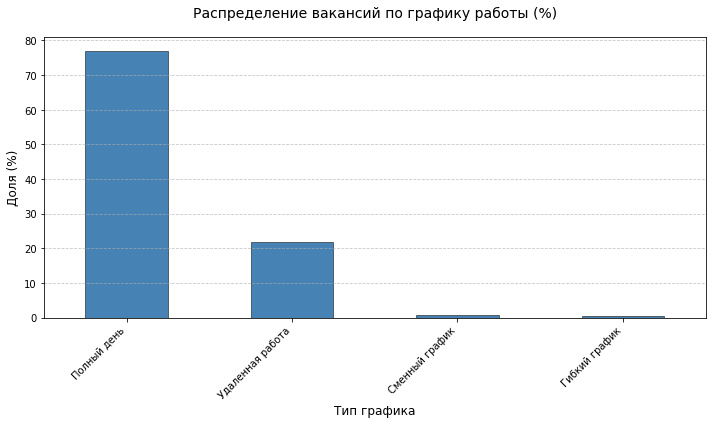

In [40]:
# Строим столбчатую диаграмму
plt.figure(figsize=(10, 6))
vacancies_schedule_pct.plot(kind='bar', color='steelblue', edgecolor='black', linewidth=0.5)

plt.title('Распределение вакансий по графику работы (%)', fontsize=14, pad=20)
plt.xlabel('Тип графика', fontsize=12)
plt.ylabel('Доля (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')  # поворачиваем подписи, чтобы не накладывались
plt.grid(axis='y', linestyle='--', alpha=0.7)  # сетка для удобства чтения
plt.tight_layout()  # автоматическая подгонка отступов
plt.show()

**Вывод:** работодатели предпочитают нанимать аналитиков на полную занятость (97,8%). Также предпочтителен 2 типа графика работы - полный рабочий день в офисе - 77% и удаленный формат работы - 21,9%.

## Определим чистые специализации аналитиков

In [41]:
# Найдем долю позиций «аналитик данных» от общего числа вакансий.
total_vacancies = len(vacancies)  # общее число вакансий

# Ищем вакансии, где в названии есть фраза «аналитик данных» (регистронезависимо)
data_analyst_vacancies = vacancies[vacancies['name'].str.contains('аналитик данных', case=False, na=False)]

data_analyst_count = len(data_analyst_vacancies)  # количество подходящих вакансий
data_analyst_share = round(data_analyst_count / total_vacancies * 100, 2)  # доля в процентах

print(f"Всего вакансий: {total_vacancies}")
print(f"Вакансий с «аналитик данных» в названии: {data_analyst_count}")
print(f"Доля: {data_analyst_share}%")



Всего вакансий: 1999
Вакансий с «аналитик данных» в названии: 301
Доля: 15.06%


Как видим доля просто "аналитик данных" маленькая, попробуем сформировать "чистые специальности" с разными вариациями названий.

In [42]:
# Определяем ключевые слова для каждой роли (регистронезависимый поиск)
categories = {
    'Аналитик данных': r'аналитик\s*данных|дата[- ]?аналитик|data[- ]?analyst|специалист.*аналитики\s*данных|junior\s*аналитик|junior\s*data\s*analyst|младший\s*аналитик',
    'Финансовый аналитик': r'финансовый\s*аналитик|financial\s*analyst|экономист.*аналитик',
    'Маркетинг-аналитик': r'маркетинг.*аналитик|аналитик\s*маркетплейсов|товарный\s*аналитик',
    'Бизнес-аналитик': r'бизнес[- ]?аналитик|business\s*analyst',
    'Системный аналитик': r'системный\s*аналитик|system\s*analyst',
    'Продуктовый аналитик': r'продуктовый\s*аналитик|product\s*analyst',
    'Инженер данных': r'инженер|engineer|инженер\s*данных|data\s*engineer',
    'Стажёр': r'стаж[её]р|начинающий\s*аналитик|intern\s*analyst|trainee\s*analyst',
    'Логист-аналитик': r'логист.*аналитик|логистический\s*аналитик',
    'BI аналитик': r'bi\s*аналитик|bi\s*analyst|business\s*intelligence',
    'Аналитик (прочее)': r'\bаналитик\b'
}

# Создаём словарь для результатов
counts = {}

for role, pattern in categories.items():
    # Ищем в столбце 'name', игнорируя регистр, и считаем количество совпадений
    count = vacancies['name'].str.contains(pattern, case=False, na=False).sum()
    counts[role] = count

# Преобразуем в Series и сортируем по убыванию
result = pd.Series(counts).sort_values(ascending=False)

print("Количество вакансий по ролям аналитиков:")
print(result)

total = len(vacancies)
print("\nВ процентах от общего числа вакансий (1999):")
print((result / total * 100).round(1).astype(str) + '%')

Количество вакансий по ролям аналитиков:
Аналитик (прочее)       1832
Аналитик данных          352
Системный аналитик       228
Финансовый аналитик      193
Бизнес-аналитик          167
Продуктовый аналитик      64
Инженер данных            38
Маркетинг-аналитик        35
Стажёр                    30
BI аналитик                6
Логист-аналитик            2
dtype: int64

В процентах от общего числа вакансий (1999):
Аналитик (прочее)       91.6%
Аналитик данных         17.6%
Системный аналитик      11.4%
Финансовый аналитик      9.7%
Бизнес-аналитик          8.4%
Продуктовый аналитик     3.2%
Инженер данных           1.9%
Маркетинг-аналитик       1.8%
Стажёр                   1.5%
BI аналитик              0.3%
Логист-аналитик          0.1%
dtype: object


**Вывод:** как видим по результатам, чаще всего вакансия описана как "аналитик", что подразумевает в себе общие черты, и где непонятно какая специализация требуется. Поэтому здесь необходимо смотреть требования к описанию вакансии.

Так как "Аналитик" пересекается с разными другими вакансиями, то проверим это пересечение.

In [43]:
# Сколько вакансий попало в несколько категорий?

# Создаём датафрейм с индикаторами
df_analysis = vacancies.copy()
for cat, pattern in categories.items():
    df_analysis[cat] = df_analysis['name'].str.contains(pattern, case=False, na=False).astype(int)

# Список колонок с категориями
cat_columns = list(categories.keys())

# Сколько категорий совпало для каждой вакансии
df_analysis['categories_count'] = df_analysis[cat_columns].sum(axis=1)

# Распределение
print("Распределение количества категорий на одну вакансию:")
print(df_analysis['categories_count'].value_counts().sort_index())

# В процентах
print("\nВ процентах:")
print((df_analysis['categories_count'].value_counts(normalize=True).sort_index() * 100).round(1))

# Сколько вакансий вообще попало хотя бы в одну категорию
at_least_one = (df_analysis['categories_count'] > 0).sum()
print(f"\nВакансий хотя бы в одной категории: {at_least_one} из {len(df_analysis)} ({at_least_one/len(df_analysis)*100:.1f}%)")
print(f"Вакансий без категории: {(df_analysis['categories_count'] == 0).sum()} ({(df_analysis['categories_count'] == 0).sum()/len(df_analysis)*100:.1f}%)")

Распределение количества категорий на одну вакансию:
0    136
1    829
2    985
3     48
4      1
Name: categories_count, dtype: int64

В процентах:
0     6.8
1    41.5
2    49.3
3     2.4
4     0.1
Name: categories_count, dtype: float64

Вакансий хотя бы в одной категории: 1863 из 1999 (93.2%)
Вакансий без категории: 136 (6.8%)


Как итог видим, что аналитик присутсвует в 93,2% вакансиях (добавляется почти к каждой вакансии, где есть слово аналитик), но мы не понимаем это аналитики данных или это другая специализация. Создадим список real_cats, где уберем "аналитик (прочее)"

In [44]:
# Посмотрим на распредение категорий без "аналитика (прочее)"
real_cats = [cat for cat in cat_columns if cat != 'Аналитик (прочее)']
df_analysis['real_categories_count'] = df_analysis[real_cats].sum(axis=1)

print("Реальное распределение (без 'Аналитик (прочее)'):")
print(df_analysis['real_categories_count'].value_counts().sort_index())
print("\nВ процентах:")
print((df_analysis['real_categories_count'].value_counts(normalize=True).sort_index() * 100).round(1))

Реальное распределение (без 'Аналитик (прочее)'):
0     934
1    1016
2      48
3       1
Name: real_categories_count, dtype: int64

В процентах:
0    46.7
1    50.8
2     2.4
3     0.1
Name: real_categories_count, dtype: float64


**Вывод:** сейчас мы получили, что большинство вакансий либо чистые (50.8%), либо без специализации (46.7%) - и тут нужно читать требования к вакансии, чтобы понять кого ищут работодатели.

Резимируем:  почти половина вакансий на рынке (934 вакансии или 46,7%) — это общие аналитики без чёткой специализации. 1016 вакансий (50.8%) относится к одной конкретной роли аналитика, которую мы создали с четкой специализацией (аналитик данных, бизнес-аналитик, системный аналитик). Также видим, что 48 вакансий (2.4%) сочетает две специализации одновременно. И одна уникальная вакансия сочетает 3 специализации. Посмотрим на эту вакансию.

In [45]:
# Найдём вакансию с 3 специализациями
max_real_cat = df_analysis[df_analysis['real_categories_count'] == 3]
print("Вакансия с 3 категориями:")
print(max_real_cat[['name'] + real_cats].to_string())  # используем real_cats, а не real_cats_list

Вакансия с 3 категориями:
                                              name  Аналитик данных  Финансовый аналитик  Маркетинг-аналитик  Бизнес-аналитик  Системный аналитик  Продуктовый аналитик  Инженер данных  Стажёр  Логист-аналитик  BI аналитик
766  Системный аналитик / Бизнес-аналитик (стажер)                0                    0                   0                1                   1                     0               0       1                0            0


Вывод - это вакансия "Системный аналитик / Бизнес-аналитик (стажер)", сочетает и системного и бизнес-аналитика и требуется новичок. 
Поисследуем чистые специальности по зарплате, региону, грейду

In [46]:
# Чистая выборка для анализа зарплат по ролям
clean_roles = df_analysis[df_analysis['real_categories_count'] == 1].copy()

print(f"Выборка для анализа: {len(clean_roles)} вакансий")
print("\nРаспределение по ролям:")
for cat in real_cats:
    count = clean_roles[clean_roles[cat] == 1].shape[0]
    if count > 0:
        print(f"  {cat}: {count} вакансий")

Выборка для анализа: 1016 вакансий

Распределение по ролям:
  Аналитик данных: 320 вакансий
  Финансовый аналитик: 186 вакансий
  Маркетинг-аналитик: 31 вакансий
  Бизнес-аналитик: 150 вакансий
  Системный аналитик: 219 вакансий
  Продуктовый аналитик: 61 вакансий
  Инженер данных: 29 вакансий
  Стажёр: 13 вакансий
  Логист-аналитик: 2 вакансий
  BI аналитик: 5 вакансий


In [47]:
clean_roles.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1016 entries, 0 to 1997
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id                     1016 non-null   int64         
 1   name                   1016 non-null   object        
 2   url                    1016 non-null   object        
 3   employer               1016 non-null   object        
 4   area                   1016 non-null   object        
 5   salary_from            260 non-null    float64       
 6   salary_to              190 non-null    float64       
 7   salary_currency        315 non-null    object        
 8   experience             1016 non-null   object        
 9   employment             1016 non-null   object        
 10  schedule               1016 non-null   object        
 11  published_date         1016 non-null   datetime64[ns]
 12  created_date           1016 non-null   datetime64[ns]
 13  Ана

Вывод: теперь у нас есть вакансии, которые требуют ТОЛЬКО ОДНУ специализацию. Например: "Аналитик данных", "Финансовый аналитик", "Системный аналитик". Такие вакансии не требуют совмещения ролей.

In [48]:
# Группируем по региону и суммируем СТРОГО по каждой чистой категории
region_analysis_clean = clean_roles.groupby('area')[real_cats].sum()

# Топ-10 регионов по общему количеству вакансий
region_analysis_clean['Всего'] = region_analysis_clean.sum(axis=1)
print("ТОП-10 РЕГИОНОВ ПО ОБЩЕМУ ЧИСЛУ ЧИСТЫХ ВАКАНСИЙ")

print(region_analysis_clean['Всего'].sort_values(ascending=False).head(10))

# Для каждой категории отдельно
print("ТОП-5 РЕГИОНОВ ДЛЯ КАЖДОЙ КАТЕГОРИИ (ЧИСТЫЕ ВАКАНСИИ)")


for cat in real_cats:
    # Проверяем, есть ли вакансии в этой категории
    total_for_cat = region_analysis_clean[cat].sum()
    if total_for_cat > 0:
        print(f"\nТоп-5 регионов для '{cat}':")
        top5 = region_analysis_clean[cat].sort_values(ascending=False).head(5)
        for region, count in top5.items():
            pct = (count / total_for_cat * 100).round(1)
            print(f"   {region}: {count} ({pct}%)")

ТОП-10 РЕГИОНОВ ПО ОБЩЕМУ ЧИСЛУ ЧИСТЫХ ВАКАНСИЙ
area
Москва             565
Санкт-Петербург     77
Алматы              61
Минск               32
Ташкент             31
Новосибирск         24
Екатеринбург        23
Нижний Новгород     22
Астана              15
Казань              15
Name: Всего, dtype: int64
ТОП-5 РЕГИОНОВ ДЛЯ КАЖДОЙ КАТЕГОРИИ (ЧИСТЫЕ ВАКАНСИИ)

Топ-5 регионов для 'Аналитик данных':
   Москва: 184 (57.5%)
   Санкт-Петербург: 19 (5.9%)
   Алматы: 16 (5.0%)
   Ташкент: 15 (4.7%)
   Екатеринбург: 9 (2.8%)

Топ-5 регионов для 'Финансовый аналитик':
   Москва: 91 (48.9%)
   Алматы: 24 (12.9%)
   Санкт-Петербург: 10 (5.4%)
   Минск: 5 (2.7%)
   Нижний Новгород: 4 (2.2%)

Топ-5 регионов для 'Маркетинг-аналитик':
   Москва: 18 (58.1%)
   Ташкент: 3 (9.7%)
   Екатеринбург: 2 (6.5%)
   Алматы: 1 (3.2%)
   Грозный: 1 (3.2%)

Топ-5 регионов для 'Бизнес-аналитик':
   Москва: 74 (49.3%)
   Санкт-Петербург: 14 (9.3%)
   Алматы: 8 (5.3%)
   Ташкент: 7 (4.7%)
   Минск: 7 (4.7%)

Топ-5 р

Теперь сравним с гибридными ролями. Возьмем датафрейм df_analysis, где содержатся все 1999, группируем по регионам и суммируем по каждой специализации. Получим вакансии, которые требуют как четкой специализации, так гибридной - две и более специализаций одновременно (*понмим, что ранее мы выяснили, что 48 сочетают в себе совмещение двух ролей и одна вакансия совмечает три роли)*. Например: "Junior Data Analyst / Business Analyst" (аналитик данных + бизнес-аналитик).

In [49]:
# Посмотрим количество аналитиков по категорям (в том числе гибридные вакансии) в разрезе регионов
region_analysis = df_analysis.groupby('area')[real_cats].sum()

# Смотрим результат
# Топ-10 регионов по общему количеству вакансий (суммируем все категории)
region_analysis['Всего'] = region_analysis.sum(axis=1)
print("\nТоп-10 регионов по общему числу вакансий:")
print(region_analysis['Всего'].sort_values(ascending=False).head(10))

# Для каждой категории отдельно с процентами
print("\nТОП-5 РЕГИОНОВ ДЛЯ КАЖДОЙ КАТЕГОРИИ (ЧИСТЫЕ ВАКАНСИИ)")

for cat in real_cats:
    # Проверяем, есть ли вакансии в этой категории
    total_for_cat = region_analysis[cat].sum()
    if total_for_cat > 0:
        print(f"\nТоп-5 регионов для '{cat}':")
        top5 = region_analysis[cat].sort_values(ascending=False).head(5)
        for region, count in top5.items():
            pct = (count / total_for_cat * 100).round(1)
            print(f"   {region}: {count} ({pct}%)")
              


Топ-10 регионов по общему числу вакансий:
area
Москва             626
Санкт-Петербург     85
Алматы              65
Минск               38
Ташкент             33
Новосибирск         26
Нижний Новгород     24
Екатеринбург        23
Казань              19
Астана              17
Name: Всего, dtype: int64

ТОП-5 РЕГИОНОВ ДЛЯ КАЖДОЙ КАТЕГОРИИ (ЧИСТЫЕ ВАКАНСИИ)

Топ-5 регионов для 'Аналитик данных':
   Москва: 206 (58.5%)
   Санкт-Петербург: 23 (6.5%)
   Алматы: 17 (4.8%)
   Ташкент: 16 (4.5%)
   Екатеринбург: 9 (2.6%)

Топ-5 регионов для 'Финансовый аналитик':
   Москва: 92 (47.7%)
   Алматы: 24 (12.4%)
   Санкт-Петербург: 10 (5.2%)
   Минск: 6 (3.1%)
   Нижний Новгород: 5 (2.6%)

Топ-5 регионов для 'Маркетинг-аналитик':
   Москва: 20 (57.1%)
   Ташкент: 3 (8.6%)
   Екатеринбург: 2 (5.7%)
   Санкт-Петербург: 2 (5.7%)
   Ростов-на-Дону: 1 (2.9%)

Топ-5 регионов для 'Бизнес-аналитик':
   Москва: 82 (49.1%)
   Санкт-Петербург: 14 (8.4%)
   Минск: 9 (5.4%)
   Алматы: 9 (5.4%)
   Новосибирск: 8

In [50]:
# Сравнение результатов
print("СРАВНЕНИЕ: Гибридные вакансии vs Чистые вакансии (Москва)")


# Данные из df_analysis (гибридные вакансии)
all_data = {
    'Аналитик данных': 206,
    'Финансовый аналитик': 92,
    'Маркетинг-аналитик': 20,
    'Бизнес-аналитик': 82,
    'Системный аналитик': 141,
    'Продуктовый аналитик': 40,
    'Инженер данных': 21,
    'Стажёр': 19,
    'Логист-аналитик': 0,
    'BI аналитик': 5
}

# Данные из clean_roles (чистые вакансии)
clean_data = {
    'Аналитик данных': 184,
    'Финансовый аналитик': 91,
    'Маркетинг-аналитик': 18,
    'Бизнес-аналитик': 74,
    'Системный аналитик': 135,
    'Продуктовый аналитик': 38,
    'Инженер данных': 14,
    'Стажёр': 7,
    'Логист-аналитик': 0,
    'BI аналитик': 4
}

print("\nКатегория                 | Чистые | Гибридные (разница)")
for cat in all_data.keys():
    all_count = all_data[cat]
    clean_count = clean_data[cat]
    hybrid_count = all_count - clean_count
    hybrid_pct = (hybrid_count / all_count * 100) if all_count > 0 else 0
    print(f"{cat:<25} {all_count:>6}      {clean_count:>6}   {hybrid_count:>6} ({hybrid_pct:.0f}%)")

СРАВНЕНИЕ: Гибридные вакансии vs Чистые вакансии (Москва)

Категория                 | Чистые | Гибридные (разница)
Аналитик данных              206         184       22 (11%)
Финансовый аналитик           92          91        1 (1%)
Маркетинг-аналитик            20          18        2 (10%)
Бизнес-аналитик               82          74        8 (10%)
Системный аналитик           141         135        6 (4%)
Продуктовый аналитик          40          38        2 (5%)
Инженер данных                21          14        7 (33%)
Стажёр                        19           7       12 (63%)
Логист-аналитик                0           0        0 (0%)
BI аналитик                    5           4        1 (20%)


Итого больше всего аналитиков разных направлений требуется в крупные столичные города.  Москва, Санкт-Петербург фигурируют на первых местах среди всех категорий вакансий.  Что пересекается с общей информацией в начале анализа.

Однако, сравнив данные чистые и гибридные специализации для рынка Москвы мы можем константировать: 

**Для начинающих (Стажёры):**
- 63% стажёрских вакансий — это гибридные роли. Компании ищут стажёров, которые готовы работать на стыке двух направлений


**Для инженеров данных:**
- 33% гибридных вакансий требуют навыков аналитика данных. Рынок хочет "инженера + аналитика" в одном лице


**Для узких специалистов:**
- Финансовый, системный, продуктовый аналитики — более защищены от гибридизации. У них меньше конкуренции со стороны смежных ролей.

In [51]:
# Посмотрим на зарплату по категориям (только рубли)
filter_analysis = df_analysis[df_analysis['salary_currency'] == 'RUR'].copy()

# Создаём среднюю зарплату (если ещё не создали)
filter_analysis['salary_mid'] = filter_analysis[['salary_from', 'salary_to']].mean(axis=1)
filter_analysis['salary_mid'] = filter_analysis['salary_mid'].fillna(filter_analysis['salary_from'])
filter_analysis['salary_mid'] = filter_analysis['salary_mid'].fillna(filter_analysis['salary_to'])

# Убираем выбросы (опционально)
filter_analysis = filter_analysis[filter_analysis['salary_mid'] <= 500000]  # убираем аномально высокие
filter_analysis = filter_analysis[filter_analysis['salary_mid'] >= 20000]   # убираем аномально низкие

# Анализируем только чистые вакансии (с одной специализацией)
clean_with_salary = filter_analysis[filter_analysis['real_categories_count'] == 1].copy()

print("Медианная зарплата по категориям:")

for cat in real_cats:
    cat_data = clean_with_salary[clean_with_salary[cat] == 1]
    if len(cat_data) > 0:
        median_salary = cat_data['salary_mid'].median()
        count = len(cat_data)
        print(f"\n{cat}: {median_salary:,.0f} руб ({count} вакансий)")

Медианная зарплата по категориям:

Аналитик данных: 100,000 руб (84 вакансий)

Финансовый аналитик: 120,000 руб (62 вакансий)

Маркетинг-аналитик: 115,000 руб (14 вакансий)

Бизнес-аналитик: 134,000 руб (31 вакансий)

Системный аналитик: 205,000 руб (53 вакансий)

Продуктовый аналитик: 160,000 руб (11 вакансий)

Инженер данных: 120,000 руб (3 вакансий)

Стажёр: 50,000 руб (7 вакансий)

Логист-аналитик: 53,831 руб (1 вакансий)

BI аналитик: 180,000 руб (1 вакансий)


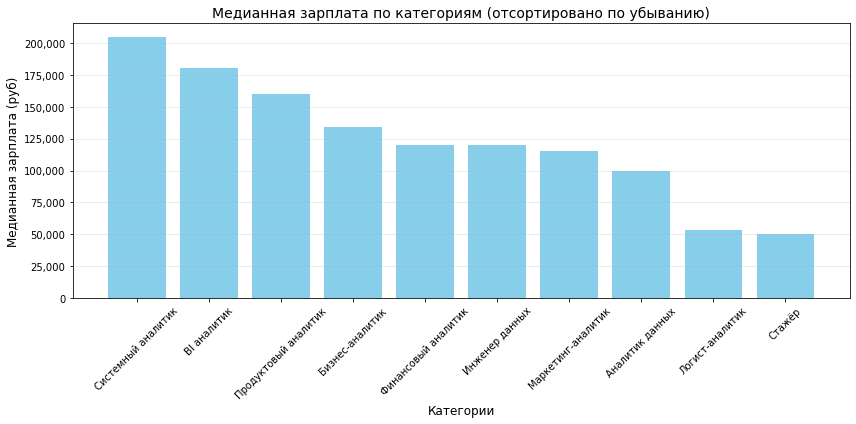

In [52]:
import matplotlib.pyplot as plt
# Собираем данные для визуализации
data_for_plot = []

for cat in real_cats:
    cat_data = clean_with_salary[clean_with_salary[cat] == 1]
    if len(cat_data) > 0:
        median_salary = cat_data['salary_mid'].median()
        count = len(cat_data)
        data_for_plot.append({'category': cat, 'median_salary': median_salary, 'count': count})

# Преобразуем в DataFrame и сортируем по убыванию медианной зарплаты
df_plot = pd.DataFrame(data_for_plot)
df_plot_sorted = df_plot.sort_values('median_salary', ascending=False)

# Создаём столбчатую диаграмму
plt.figure(figsize=(12, 6))
plt.bar(df_plot_sorted['category'], df_plot_sorted['median_salary'], color='skyblue')
plt.title('Медианная зарплата по категориям (отсортировано по убыванию)', fontsize=14)
plt.xlabel('Категории', fontsize=12)
plt.ylabel('Медианная зарплата (руб)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

# Форматируем значения на оси Y
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))
plt.tight_layout()
plt.show()


**Вывод:** видим, что наибольшая медианная зарплата представлена у системных аналитиков (205000 руб), далее идут BI-аналитики (180000 руб), потом продуктовые аналитики (160000 руб), бизнес-аналитики (134000 руб), аналитик данных (100000 руб) и на последнем месте стажеры (с зп 50000 руб.)

In [53]:
# Изучим распределение по работодателям по чистым вакансиям
# Компактный код для топ-5 работодателей по категориям

print("ТОП-5 Работодателей по каждой категории\n")

for cat in real_cats:
    cat_data = clean_roles[clean_roles[cat] == 1]
    if len(cat_data) > 0:
        print(f"\n{cat} ({len(cat_data)} вакансий):")
        print(cat_data['employer'].value_counts().head(5).to_string())

ТОП-5 Работодателей по каждой категории


Аналитик данных (320 вакансий):
СБЕР                                                   21
Ozon                                                   14
ИЦ АЙ-ТЕКО                                              5
Центральный банк Российской Федерации (Банк России)     4
RWB (Wildberries & Russ)                                4

Финансовый аналитик (186 вакансий):
АйСи Инвест    5
Т-Банк         4
Спортмастер    3
MERLION        3
Ozon           2

Маркетинг-аналитик (31 вакансий):
Страна Девелопмент          2
Мэлон Фэшн Груп             1
СмартТайм                   1
Грандфаянс                  1
Группа компаний «Триумф»    1

Бизнес-аналитик (150 вакансий):
СБЕР              6
Банк ВТБ (ПАО)    4
ЛУКОЙЛ            3
Банк ПСБ          2
HALEON            2

Системный аналитик (219 вакансий):
СБЕР          8
ИЦ АЙ-ТЕКО    7
СберЛизинг    4
Ред Софт      4
Т1            4

Продуктовый аналитик (61 вакансий):
HeadHunter           3
Горбилет            

In [54]:
# Изучим распределение по работодателям по всем специализированным вакансиям (чистые + гибридные)

print("ТОП-5 работодателей по каждой категории\n")

for cat in real_cats:
    cat_data = df_analysis[df_analysis[cat] == 1]
    if len(cat_data) > 0:
        print(f"\n{cat} ({len(cat_data)} вакансий):")
        print(cat_data['employer'].value_counts().head(5).to_string())

ТОП-5 работодателей по каждой категории


Аналитик данных (352 вакансий):
СБЕР                                                   21
Ozon                                                   15
МТС                                                     7
Центральный банк Российской Федерации (Банк России)     6
ИЦ АЙ-ТЕКО                                              5

Финансовый аналитик (193 вакансий):
Т-Банк         5
АйСи Инвест    5
MERLION        3
Спортмастер    3
Добрый         2

Маркетинг-аналитик (35 вакансий):
Страна Девелопмент                       2
Мэлон Фэшн Груп                          1
Гилмарк агентство интернет-маркетинга    1
Rizz.Market                              1
Garage Eight                             1

Бизнес-аналитик (167 вакансий):
СБЕР              6
Банк ВТБ (ПАО)    5
ЛУКОЙЛ            3
Банк ПСБ          2
HALEON            2

Системный аналитик (228 вакансий):
СБЕР          8
ИЦ АЙ-ТЕКО    7
СберЛизинг    4
Т1            4
Ред Софт      4

Продуктовый ан

**Вывод:** рассмотрим компании и их предпочтения (*наблюдения за март-апрель 2026 года ,возможно, тенденция на более длительном сроке будет другая:)*
    
- СБЕР абсолютный лидер по найму аналитиков. Лидирует в категориях: Аналитик данных (21), Бизнес-аналитик (6), Системный аналитик (8). Предпочитает чистых специалистов (разница между таблицами минимальна). 


- МТС активно нанимает гибридных аналитиков и стажёров


- Т-Банк лидер по найму финансовых аналитиков и стажёров


- Ozon	растёт спрос на аналитиков данных (14→15, +1 гибрид)


- ИЦ АЙ-ТЕКО стабилен в чистых аналитиках (5) и системных аналитиках (7).

Если рассмотрим по категориям, то увидим, что: 

- "Аналитик данных" -	МТС (+7), Ozon (+1)	- ищут аналитиков с доп. навыками
- "Стажёр" -	МТС (+4), Aston (+3), ЦБ (+2) -	стажировки часто совмещают роли
- "Инженер данных" - Prime Sport (+3)	- смотрят на инженеров с аналитическими задачами
- "Финансовый аналитик"- Т-Банк (+5), Добрый (+2)	- интересны финансисты со смежными функциями
- "Продуктовый аналитик"- VK (+2)	- нужны продуктовые аналитики-универсалы

In [55]:
# Изучим распределение грейдов
# Добавим столбец с категорией грейдов
mapping = {
    'От 1 года до 3 лет': 'джун',
    'От 3 до 6 лет': 'мидл',
    'Более 6 лет': 'сеньор',
    'Нет опыта': 'стажёр'
}

clean_roles['experience_category'] = clean_roles['experience'].map(mapping)

display(clean_roles.head())

,id,name,url,employer,area,salary_from,salary_to,salary_currency,experience,employment,...,Системный аналитик,Продуктовый аналитик,Инженер данных,Стажёр,Логист-аналитик,BI аналитик,Аналитик (прочее),categories_count,real_categories_count,experience_category
0,131508219,Аналитик данных,https://hh.ru/vacancy/131508219,СП ООО AZIA METALL PROF,Самарканд,6000000.0,12000000.0,UZS,От 1 года до 3 лет,Полная занятость,...,0,0,0,0,0,0,1,2,1,джун
1,132118624,Аналитик данных,https://hh.ru/vacancy/132118624,Служба занятости населения города Москвы,Москва,65000.0,65000.0,RUR,От 1 года до 3 лет,Полная занятость,...,0,0,0,0,0,0,1,2,1,джун
2,131775933,Аналитик данных,https://hh.ru/vacancy/131775933,Газпром нефть,Екатеринбург,NaN,NaN,NaN,От 1 года до 3 лет,Полная занятость,...,0,0,0,0,0,0,1,2,1,джун
3,131607371,Аналитик данных,https://hh.ru/vacancy/131607371,Алюсофт,Минск,NaN,NaN,NaN,От 1 года до 3 лет,Полная занятость,...,0,0,0,0,0,0,1,2,1,джун
4,132123805,Дата-аналитик,https://hh.ru/vacancy/132123805,СБЕР,Москва,NaN,NaN,NaN,От 1 года до 3 лет,Полная занятость,...,0,0,0,0,0,0,1,2,1,джун


In [56]:
# Отбираем чистые вакансии (с одной специализацией)
clean_vacancies = clean_roles[clean_roles['real_categories_count'] == 1].copy()

# Создаём колонку с названием специализации (какая категория = 1)
real_cats = [col for col in clean_roles.columns if col in ['Аналитик данных', 'Финансовый аналитик', 'Маркетинг-аналитик', 'Бизнес-аналитик', 'Системный аналитик', 'Продуктовый аналитик', 'Инженер данных', 'Стажёр', 'Логист-аналитик', 'BI аналитик']]

# Находим специализацию для каждой чистой вакансии
for cat in real_cats:
    clean_vacancies.loc[clean_vacancies[cat] == 1, 'specialization'] = cat

# 1. Распределение грейдов в целом
print("Распределение грейдов среди чистых вакансий")


grade_total = clean_vacancies.groupby('experience_category').size()
grade_pct = clean_vacancies.groupby('experience_category').size() / len(clean_vacancies) * 100

result = pd.DataFrame({
    'Количество': grade_total,
    'Процент': grade_pct.round(1)
})
display(result)

Распределение грейдов среди чистых вакансий


,Количество,Процент
experience_category,,
джун,481,47.3
мидл,453,44.6
сеньор,36,3.5
стажёр,46,4.5


In [57]:
# Распределение грейдов по каждой специализации
print("Распределение грейдов по специализации")

# Группируем по специализации и грейду
grade_by_spec = clean_vacancies.groupby(['specialization', 'experience_category']).size().unstack(fill_value=0)

# Добавляем строку с итогом
grade_by_spec['Всего'] = grade_by_spec.sum(axis=1)

# Сортируем по убыванию общего количества
grade_by_spec = grade_by_spec.sort_values('Всего', ascending=False)

display(grade_by_spec)

# Посчитаем проценты по специализациям
print("Доли грейдов внутри каждой специализации (%)")
grade_by_specc = grade_by_spec.div(grade_by_spec['Всего'], axis=0) * 100

display(grade_by_specc.round(1))

Распределение грейдов по специализации


experience_category,джун,мидл,сеньор,стажёр,Всего
specialization,,,,,
Аналитик данных,187,109,2,22,320
Системный аналитик,62,135,19,3,219
Финансовый аналитик,98,78,5,5,186
Бизнес-аналитик,72,69,6,3,150
Продуктовый аналитик,27,30,3,1,61
Маркетинг-аналитик,18,13,0,0,31
Инженер данных,11,15,1,2,29
Стажёр,3,0,0,10,13
BI аналитик,1,4,0,0,5


Доли грейдов внутри каждой специализации (%)


experience_category,джун,мидл,сеньор,стажёр,Всего
specialization,,,,,
Аналитик данных,58.4,34.1,0.6,6.9,100.0
Системный аналитик,28.3,61.6,8.7,1.4,100.0
Финансовый аналитик,52.7,41.9,2.7,2.7,100.0
Бизнес-аналитик,48.0,46.0,4.0,2.0,100.0
Продуктовый аналитик,44.3,49.2,4.9,1.6,100.0
Маркетинг-аналитик,58.1,41.9,0.0,0.0,100.0
Инженер данных,37.9,51.7,3.4,6.9,100.0
Стажёр,23.1,0.0,0.0,76.9,100.0
BI аналитик,20.0,80.0,0.0,0.0,100.0


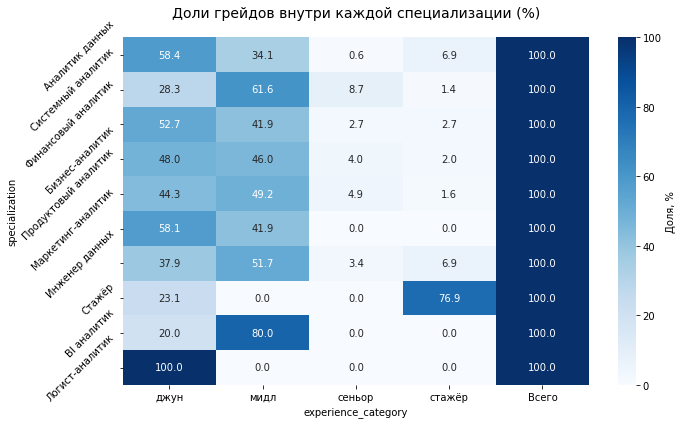

In [58]:
# Визуализируем доли грейдов внутри каждой специализации через тепловую карту
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.heatmap(
    grade_by_specc,
    annot=True,           # отображаем значения в ячейках
    fmt='.1f',         # формат: 1 знак после запятой
    cmap='Blues',      # цветовая схема
    cbar_kws={'label': 'Доля, %'}  # подпись цветовой шкалы
)
plt.title('Доли грейдов внутри каждой специализации (%)', fontsize=14, pad=20)
plt.xticks(rotation=0)  # горизонтальные подписи по оси X
plt.yticks(rotation=45) # вертикальные подписи по оси Y
plt.tight_layout()
plt.show()


**Вывод:** больше всего требуются на рынке джуны (47,3%) - 481 вакансия; далее идут мидл (44.6%) - 453 вакансии; стажеры (4,5%) - 46 вакансий; и меньше всех требуется сеньоров (3,5%) - 36 вакансий. 

Строит обратить внимание, что у аналитиков данных чаще требуются джуны (58,4%), а вот у системных аналитиков больше требуются именно мидл с опытом работы от 3 до 6 лет. 

In [59]:
# Теперь сравним с общей базой всех вакансий
# Анализ распределения грейдов среди ВСЕХ вакансий (df_analysis)

# Добавляем колонку с грейдами в df_analysis
mapping = {
    'От 1 года до 3 лет': 'джун',
    'От 3 до 6 лет': 'мидл',
    'Более 6 лет': 'сеньор',
    'Нет опыта': 'стажёр'
}

df_analysis['experience_category'] = df_analysis['experience'].map(mapping)


# Общее распределение грейдов
grade_total_all = df_analysis['experience_category'].value_counts()
grade_pct_all = df_analysis['experience_category'].value_counts(normalize=True) * 100

result_all = pd.DataFrame({
    'Количество': grade_total_all,
    'Процент': grade_pct_all.round(1)
})
print("\nОбщее распределение:")
display(result_all)


Общее распределение:


,Количество,Процент
джун,999,50.0
мидл,819,41.0
стажёр,110,5.5
сеньор,71,3.6


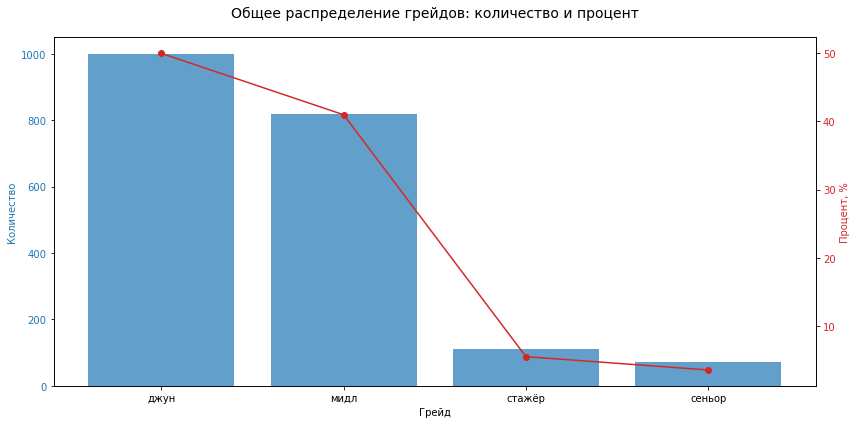

In [60]:
# Визуализация

fig, ax1 = plt.subplots(figsize=(12, 6))

# Первая ось Y — количество
color1 = 'tab:blue'
ax1.set_xlabel('Грейд')
ax1.set_ylabel('Количество', color=color1)
bars1 = ax1.bar(grade_total_all.index, grade_total_all.values, color=color1, alpha=0.7, label='Количество')
ax1.tick_params(axis='y', labelcolor=color1)

# Вторая ось Y — процент
ax2 = ax1.twinx()
color2 = 'tab:red'
ax2.set_ylabel('Процент, %', color=color2)
ax2.plot(grade_pct_all.index, grade_pct_all.values, color=color2, marker='o', label='Процент')
ax2.tick_params(axis='y', labelcolor=color2)

# Общие настройки
plt.title('Общее распределение грейдов: количество и процент', fontsize=14, pad=20)
fig.tight_layout()
plt.show()


In [61]:
# Сравнение распределения грейдов: чистые vs все вакансии

print(" Сравнение распределения грейдов")

# Чистые вакансии (clean_roles)
clean_grades = clean_roles['experience_category'].value_counts()
clean_total = len(clean_roles)

# Все вакансии (df_analysis)
# Добавляем колонку с грейдами в df_analysis
df_analysis['experience_category'] = df_analysis['experience'].map(mapping)
all_grades = df_analysis['experience_category'].value_counts()
all_total = len(df_analysis)

# Сравнение
print("\nРаспределение грейдов:")
print(f"\n{'Грейд':<10} {'Чистые вакансии':<20} {'Все вакансии':<20} {'Разница':<15}")
print("-" * 70)

for grade in ['стажёр', 'джун', 'мидл', 'сеньор']:
    clean_count = clean_grades.get(grade, 0)
    clean_pct = clean_count / clean_total * 100
    
    all_count = all_grades.get(grade, 0)
    all_pct = all_count / all_total * 100
    
    diff_count = all_count - clean_count
    diff_pct = all_pct - clean_pct
    
    print(f"{grade:<10} {clean_count:>4} ({clean_pct:>5.1f}%)     {all_count:>4} ({all_pct:>5.1f}%)     {diff_count:>+4} ({diff_pct:>+5.1f}%)")

    print(f"\n{'Итого':<10} {clean_total:>4} (100%)     {all_total:>4} (100%)")

 Сравнение распределения грейдов

Распределение грейдов:

Грейд      Чистые вакансии      Все вакансии         Разница        
----------------------------------------------------------------------
стажёр       46 (  4.5%)      110 (  5.5%)      +64 ( +1.0%)

Итого      1016 (100%)     1999 (100%)
джун        481 ( 47.3%)      999 ( 50.0%)     +518 ( +2.6%)

Итого      1016 (100%)     1999 (100%)
мидл        453 ( 44.6%)      819 ( 41.0%)     +366 ( -3.6%)

Итого      1016 (100%)     1999 (100%)
сеньор       36 (  3.5%)       71 (  3.6%)      +35 ( +0.0%)

Итого      1016 (100%)     1999 (100%)


**Вывод:** таким образом:
- Junior-специалисты, младшие аналитики очень часто совмещают несколько ролей. Компании охотно берут начинающих на гибридные позиции. Рынок для Junior большой, но часто с расширенными требованиями. 

- Middle-специалисты реже участвуют в гибридных ролях. Это самая стабильная часть рынка. Компании, видимо, предпочитают Middle на чётких позициях

- Senior - самая стабильная категория. Опытные специалисты редко работают на гибридных позициях. Спрос на Senior стабильный.

- Стажёрские позиции почти всегда гибридные. Стажёр = стажёр + какая-то основная роль.


## Выводы и рекомендации

**Общие выводы:**

Данные получены с сайта hh.ru через API путем скачивания открытых данных без регистрации и оформления токена. Срез данных представлен с 23 марта 2026 года по 14 апреля 2026 года. В итоговом ощущённом датафрейме всего 13 столбцов и 1999 строк. 

- Аналитики востребованы на рынке труда, особенно в крупных столичных городах – выделяется Москва и Санкт-Петербург, а также активно ищут аналитиков в странах СНГ – Алматы, Минска, Ташкента. 
- Срез вакансий с 23 марта 2026 года по 14 апреля 2026 года показал, что наиболее востребованы аналитики были: в банковском секторе (Сбер, Т-Банк, Альфа-багк, банк России, Россельхозбанк), e-commers (Озон, Wildberries & Russ), телекомы (МТС, Ростелеком), компании IT-направления (ИЦ АЙ-ТЕКО) и ритейл (Магнит, Спортмастер).
- Средняя медианная зарплата аналитиков колеблется от 100 000 руб. до 130 000 руб, в долларах - 1450 дол. до 2750 дол.
- Работодатели предпочитают нанимать аналитиков на полную занятость (97,8%). Также предпочтительны 2 типа графика работы - полный рабочий день в офисе - 77% и удаленный формат работы - 21,9%.


Так как слово **«аналитик»** встречаются в вакансиях в 93,2% случаях объявления, но при этом непонятна специализация данных аналитиков (для этого необходимо смотреть требования к вакансии), мы сформировали чистые категории специализаций аналитиков: 

- Аналитик данных: 320 вакансий
- Финансовый аналитик: 186 вакансий
- Маркетинг-аналитик: 31 вакансий
- Бизнес-аналитик: 150 вакансий
- Системный аналитик: 219 вакансий
- Продуктовый аналитик: 61 вакансий
- Инженер данных: 29 вакансий
- Стажёр: 13 вакансий
- Логист-аналитик: 2 вакансий
- BI аналитик: 5 вакансий

Всего получилось 1016 вакансий (50.8%), которые относится к одной конкретной роли аналитика. Почти половина вакансий на рынке (934 вакансии или 46,7%) — это общие аналитики без чёткой специализации. И 49 объявлений – это гибридные вакансии с несколькими ролями одновременно. 

*Посмотрим на основные тренды аналитиков данных, продуктовых аналитиков, BI аналитик, бизнес-аналитиков, системный аналитиков, финансовых аналитиков:*


- **Региональная особенность.** Все чистые категории аналитиков имеют спрос в крупных города, особенно в Москве и Санкт-Петербурге. При этом при сравнении чистых и гибридных специальностей на рынке Москвы формируется тренд на **«универсальности специалистов»**, так стажеры – это чаще гибридные роли. У инженеров данных требуются знания и навыки аналитиков данных. 


- **Зарплата.** Наибольшая медианная зарплата представлена у системных аналитиков (205 000 руб), далее идут BI-аналитики (180 000 руб), потом продуктовые аналитики (160 000 руб), бизнес-аналитики (134 000 руб), аналитик данных (100 000 руб) и на последнем месте стажеры (с зп 50000 руб.)


- **Распределение по работодателям.** СБЕР абсолютный лидер по найму аналитиков. Лидирует в категориях: Аналитик данных (21), Бизнес-аналитик (6), Системный аналитик (8). Предпочитает чистых специалистов (разница между таблицами минимальна).МТС активно нанимает гибридных аналитиков и стажёров. Т-Банк лидер по найму финансовых аналитиков и стажёров. Ozon растёт спрос на аналитиков данных (14→15, +1 гибрид). ИЦ АЙ-ТЕКО стабилен в чистых аналитиках (5) и системных аналитиках (7).


- **Тренд на универсальность можно увидеть и по работодателям.** Так "Аналитик данных" - МТС (+7), Ozon (+1) - ищут аналитиков с дополнительными навыками. "Стажёр" - МТС (+4), Aston (+3), ЦБ (+2) - стажировки часто совмещают роли. "Инженер данных" - Prime Sport (+3) - смотрят на инженеров с аналитическими задачами. "Финансовый аналитик"- Т-Банк (+5), Добрый (+2) - интересны финансисты со смежными функциями. "Продуктовый аналитик"- VK (+2) - нужны продуктовые аналитики-универсалы.


- **Распределение по грейдам.** Среди чистых специальностей на рынке труда больше всего требуются джуны (47,3%) - 481 вакансия; далее идут мидл (44.6%) - 453 вакансии; стажеры (4,5%) - 46 вакансий; и меньше всех требуется сеньоров (3,5%) - 36 вакансий. Эта же структура сохраняется и при общем рынке. 


- **Востребованность грейдов.** Так у аналитиков данных чаще требуются джуны (58,4%), а вот у системных аналитиков больше требуются именно мидл с опытом работы от 3 до 6 лет.


- **Тренд на универсальность прослеживается и по грейдам.** **Junior-специалисты (младшие аналитики)** очень часто совмещают несколько ролей. Компании охотно берут начинающих на гибридные позиции. Рынок для Junior большой, но часто с расширенными требованиями. **Middle-специалисты** реже участвуют в гибридных ролях. Это самая стабильная часть рынка. Компании, видимо, предпочитают Middle на чётких позициях. **Senior** - самая стабильная категория. Опытные специалисты редко работают на гибридных позициях. Спрос на Senior стабильный. **Стажёрские позиции** почти всегда гибридные. Стажёр = стажёр + какая-то основная роль.